In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker 
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colours = cm.viridis(np.linspace(0,1,5))
primary_colours = viridis_colours[0]
secondary_colours = viridis_colours[1]
accent_colours = viridis_colours[2]
danger_colours = '#800000'
neutral_colours = viridis_colours[4]
custom_palette = viridis_colours

In [9]:
df = pd.read_csv('DataCoSupplyDataset.csv', encoding='latin-1')

In [10]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [11]:
df = pd.read_csv('DataCoSupplyDataset.csv', encoding='latin-1')

In [12]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [13]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\Missing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [14]:
df['Benefit per order'] == df['Order Profit Per Order']

0         True
1         True
2         True
3         True
4         True
          ... 
180514    True
180515    True
180516    True
180517    True
180518    True
Length: 180519, dtype: bool

In [15]:
(df['Benefit per order'] == df['Order Profit Per Order']).value_counts()

True    180519
Name: count, dtype: int64

In [16]:
df['Product Status'].value_counts()

Product Status
0    180519
Name: count, dtype: int64

In [17]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Customer State',
    'Order State',
    'Market']

#dropping column that are either missing 
df = df.drop(columns=columns_to_drop,errors='ignore')

#removing canceled order 
df = df[df['Delivery Status'] != 'Shipping canceled']

#Stardard data conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

print('rows, cols:', df.shape)
print('\nMissing values (top5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 22)

Missing values (top5):
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [18]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Category Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,0.29,327.75,91.250000,Southeast Asia,COMPLETE,73,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,-0.80,327.75,-249.089996,South Asia,PENDING,73,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,-0.80,327.75,-247.779999,South Asia,CLOSED,73,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,0.08,327.75,22.860001,Oceania,COMPLETE,73,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,73,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [19]:
for col in df.columns:
    if df[col].nunique()< 10:
        print(f'\n{col} values counts:')
        print(df[col].value_counts())


Type values counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) values counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) values counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status values counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk values counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country values counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment values counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status values counts:
Order Status
CO

In [20]:
# calculating order processing time and delay

df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Category Id,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,31.856065,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,2.000000,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,18.000000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,29.000000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,45.000000,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,76.000000,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,15.642216,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [21]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [22]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'Order Country', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Category Id', 'Product Name',
       'Product Price', 'shipping date (DateOrders)', 'Shipping Mode',
       'Order Processing Time', 'Delay', 'Is_Delayed', 'order_month',
       'order_day', 'order_hour'],
      dtype='str')

In [23]:
df['Order Profit Per Order']

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 172765, dtype: float64

In [24]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [25]:
# Profitability Flag based on Order Profit Per Order

df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 
    'Profit',
    np.where(
        df['Order Profit Per Order'] < 0, 
        'Loss',
        'Break-even'
    )
)

df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [26]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: proportion, dtype: float64

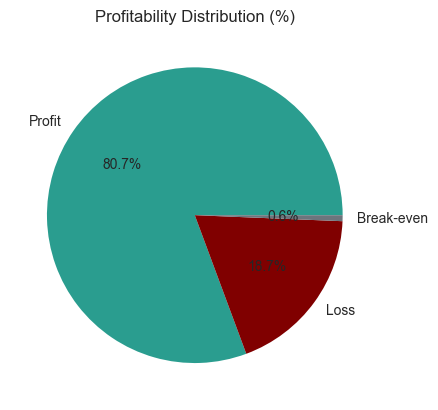

In [27]:
# define colors first
accent_color = '#2a9d8f'     
danger_color = '#800000'     
secondary_color = '#6c757d'  # 

# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.title('Profitability Distribution (%)')
plt.show()

In [28]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['Late Delivery %'] = (len(delayed_df) / len(df)) * 100
metrics['On Time Delivery %'] = 100 - metrics['Late Delivery %']

metrics['Late Deliveries'] = float(metrics['Late Deliveries'])
metrics['Total Orders'] = float(metrics['Total Orders'])

metrics['Late Delivery %'] = (metrics['Late Deliveries'] / metrics['Total Orders']) * 100

metrics['Total Profit'] = float(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = float(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())


print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765.00
Late Deliveries: 94523.00
Late Delivery %: 54.71
On Time Delivery %: 45.29
Total Profit: 7514813.81
Total Loss due to delays: 2055765.16


In [29]:
profit_metrics =(
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

In [30]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [31]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()


In [32]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay_distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


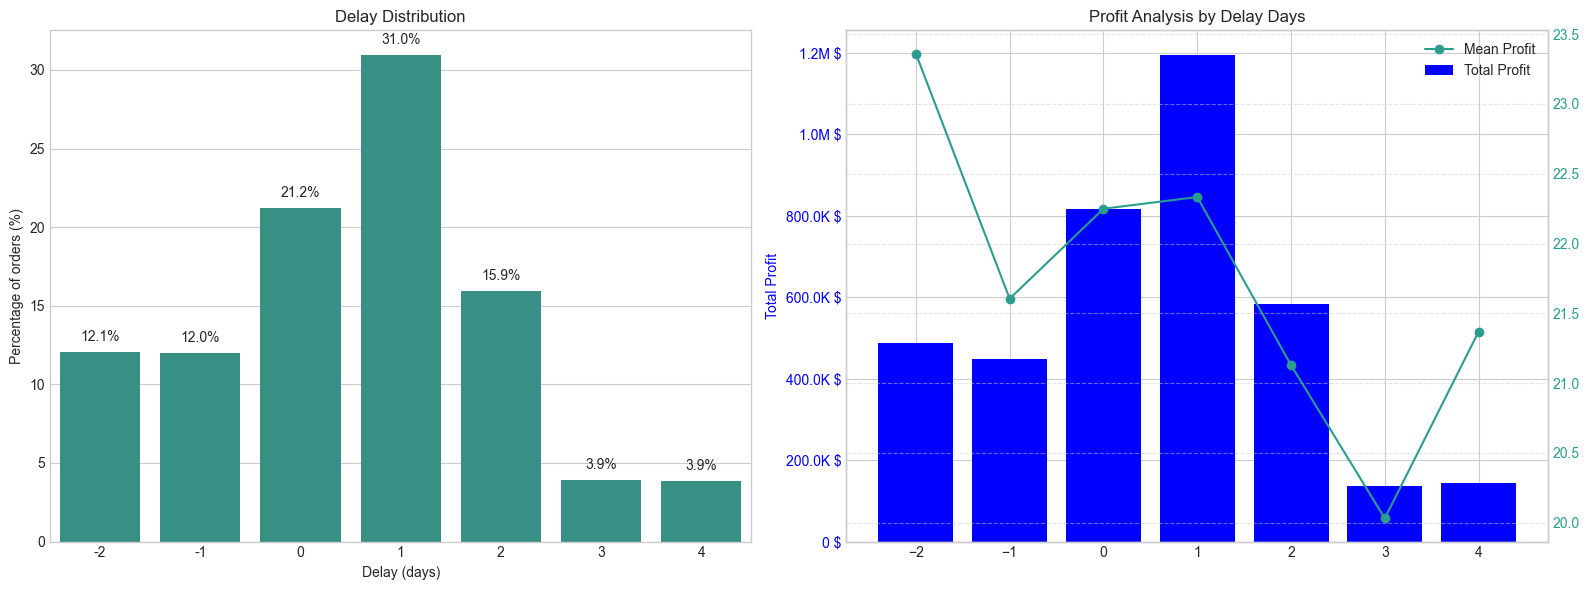

In [33]:
delay_distribution.columns =['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay_distribution (%):")
display(delay_distribution)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')

# Percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )
    
# Second subplot: Profit Analysis
primary_color = 'blue' 

ax2.set_ylabel('Total Profit', color=primary_color)
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

primary_color = 'blue'
ax2.tick_params(axis='y', labelcolor=primary_color)

# Secondary axis
ax3 = ax2.twinx()

ax2.tick_params(axis='y', labelcolor='blue')

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    label='Mean Profit',
    color=accent_color
)

ax3.tick_params(axis='y', labelcolor=accent_color)

# Format total profit axis (K, M)

def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# Title & Legend
ax3.set_title('Profit Analysis by Delay Days')

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(lines + lines2, labels + labels2, loc='upper right')

# Grid
ax3.grid(True, linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()
plt.show()

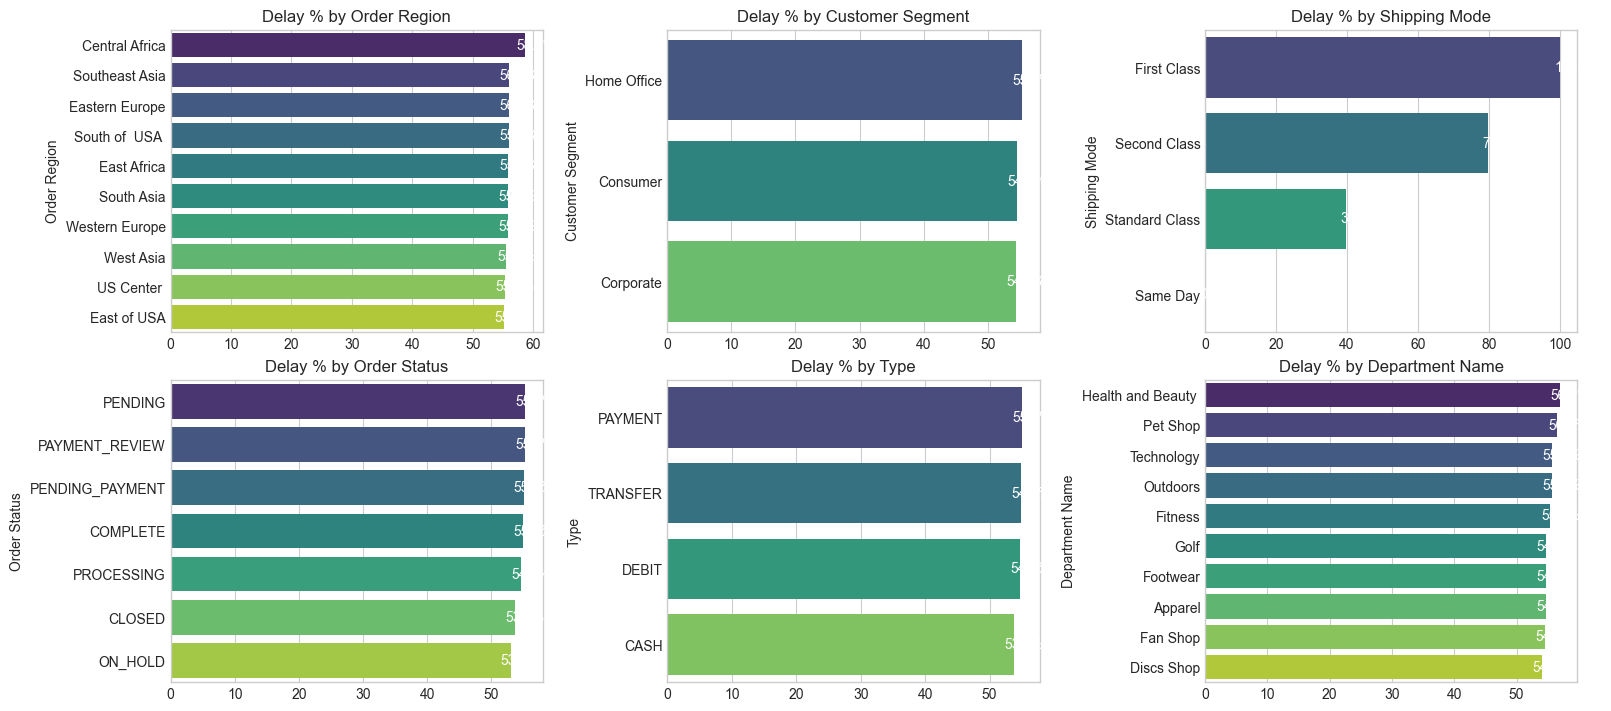

In [34]:
# Function to compute delay percentage by category
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    
    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    
    return cat_df


# Categories to analyze
categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]


# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()


# Plot each category
for ax, category in zip(axes, categories):
    
    cat_df = compute_delay_pct_by_category(category)
    
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    
    # Add percentage text on bars
    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 1.5,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )


plt.show()

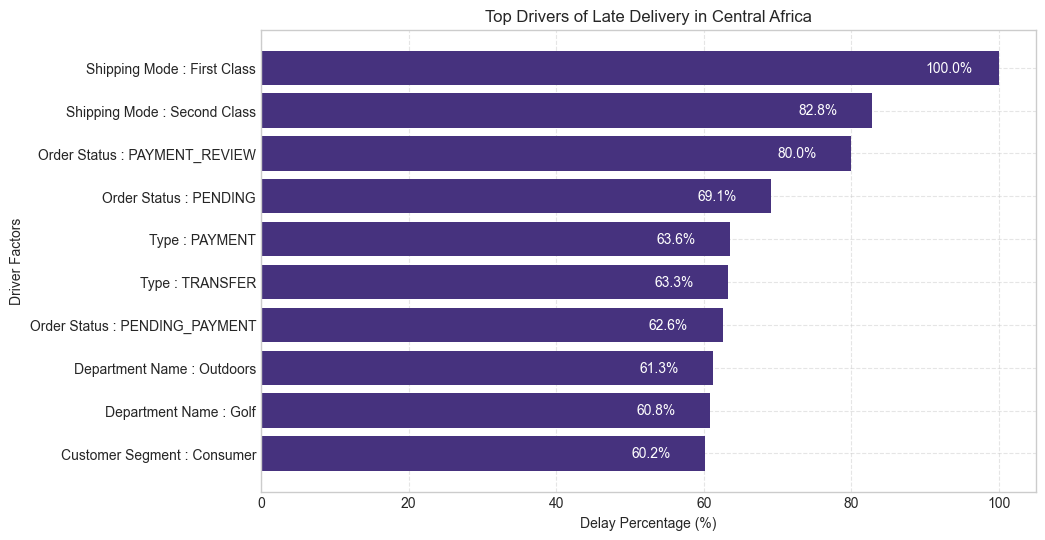

In [35]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]
    
    all_factors = []
    
    for factor in drivers:
        
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )
    
    # Combine all drivers
    final_df = pd.concat(all_factors)
    
    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().invert_yaxis()
    
    # Add text on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )
    
    plt.show()


# Run example
top_drivers_for_region('Central Africa')

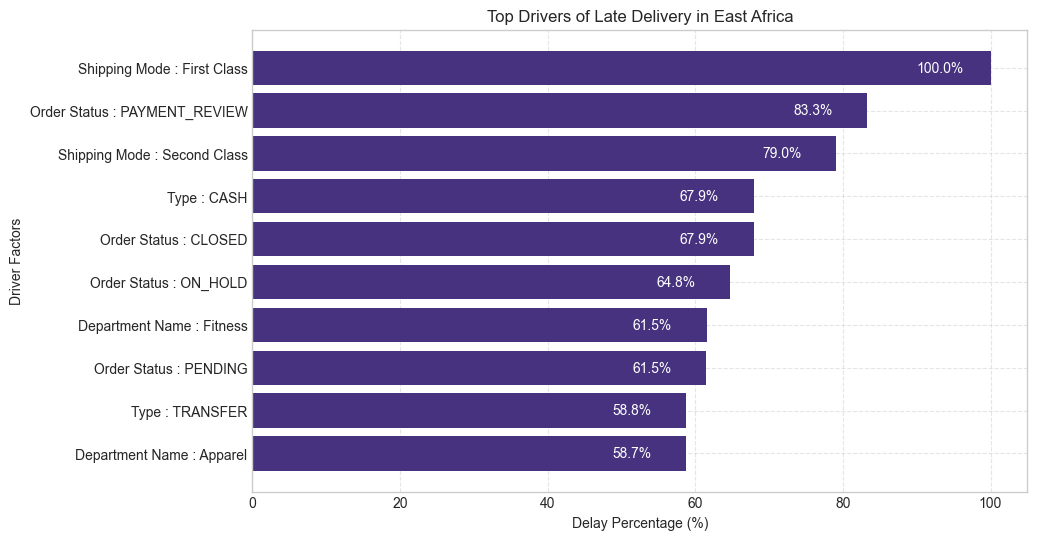

In [36]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]
    
    all_factors = []
    
    for factor in drivers:
        
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )
    
    # Combine all drivers
    final_df = pd.concat(all_factors)
    
    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().invert_yaxis()
    
    # Add text on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )
    
    plt.show()


# Run example
top_drivers_for_region('East Africa')

In [37]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.750000,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.750000,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,327.750000,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,...,399.980011,2016-01-20 03:40:00,Standard Class,4,0,False,1,Saturday,3,Profit
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-19 01:34:00,Second Class,3,1,True,1,Saturday,1,Loss
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-20 21:00:00,Standard Class,5,1,True,1,Friday,21,Profit
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,...,399.980011,2016-01-18 20:18:00,Standard Class,3,-1,False,1,Friday,20,Profit


In [38]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [39]:
# Delay % by Month, Day of Week, Hour

# Delay by Month
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


# Delay by Day
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


# Delay by Hour
delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [40]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


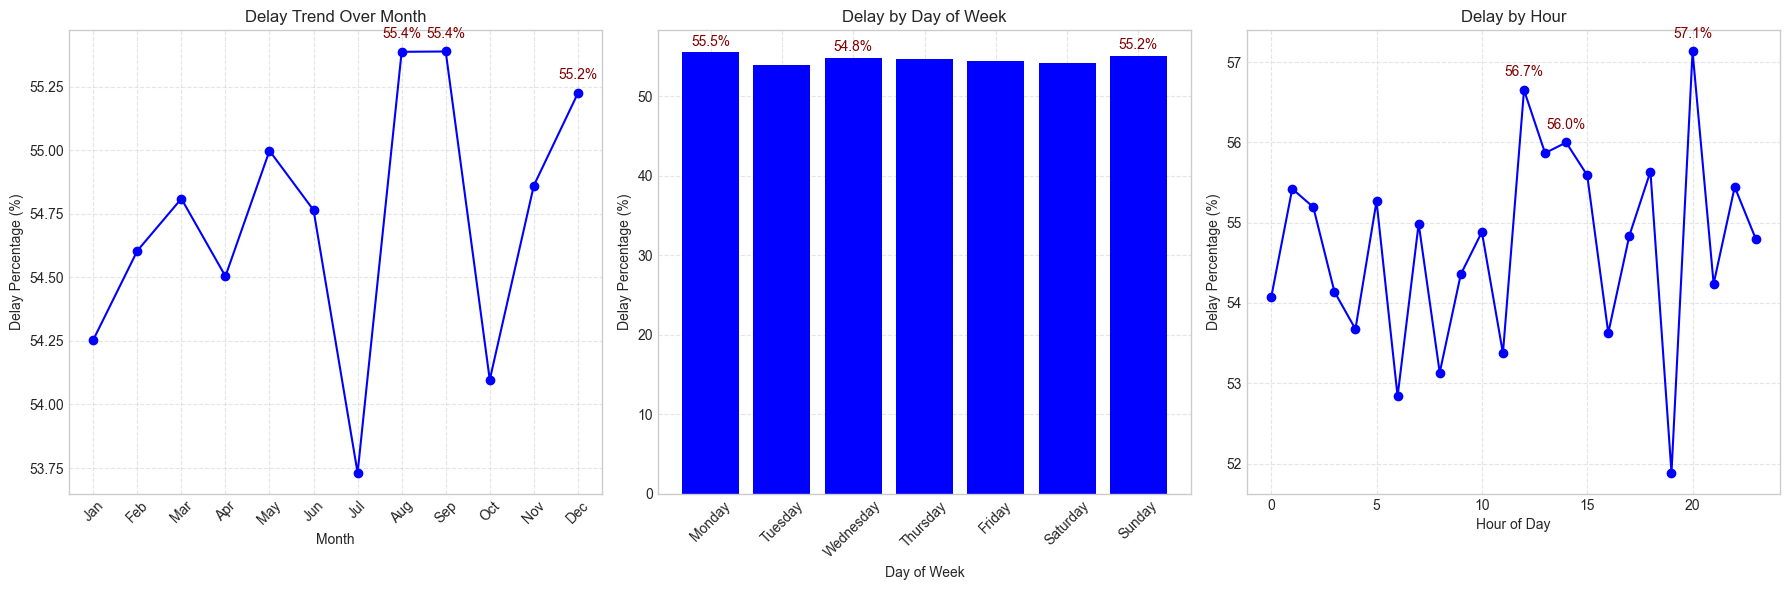

In [41]:
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))


# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'],
         marker='o', color=primary_color)

ax1.set_title("Delay Trend Over Month")
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

ax1.grid(True, linestyle='--', alpha=0.5)

# Annotate top 3 months
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_month'], row['delay_pct']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'],
        color=primary_color)

ax2.set_title("Delay by Day of Week")
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")

ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)


# Annotate top 3 days
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5,
             f"{height:.1f}%",
             ha='center', va='bottom',
             fontsize=10,
             color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'],
         marker='o', color=primary_color)

ax3.set_title("Delay by Hour")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")

ax3.grid(True, linestyle='--', alpha=0.5)


# Annotate top 3 hours
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_hour'], row['delay_pct']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color=danger_color)

plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,  precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [44]:
X = df[['Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Customer Segment',
        'Department Name',
        'Order Region',
        'Shipping Mode',
        'order_month',
        'order_hour']]

y = df['Late_delivery_risk']

In [45]:
# Get categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.copy()

print("Shape after freq+target encoding:", X_encoded.shape)

# Use encoded features for modeling
X = X_encoded

# Train/test split after encoding
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [46]:
X_encoded

,Type,Days for shipment (scheduled),Category Name,Customer Segment,Department Name,Order Region,Shipping Mode,order_month,order_hour
0,0.401094,4,0.001945,0.517582,0.013741,0.052881,0.597071,1,22
1,0.243851,4,0.001945,0.517582,0.013741,0.043151,0.597071,1,12
2,0.113542,4,0.001945,0.517582,0.013741,0.043151,0.597071,1,12
3,0.401094,4,0.001945,0.178375,0.013741,0.056337,0.597071,1,11
4,0.241513,4,0.001945,0.304043,0.013741,0.056337,0.597071,1,11
...,...,...,...,...,...,...,...,...,...
180514,0.113542,4,0.096055,0.178375,0.370636,0.040361,0.597071,1,3
180515,0.401094,2,0.096055,0.304043,0.370636,0.040361,0.195676,1,1
180516,0.243851,4,0.096055,0.304043,0.370636,0.056337,0.597071,1,21
180517,0.241513,4,0.096055,0.517582,0.370636,0.056337,0.597071,1,20


In [48]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [49]:
print("Before balancing(train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing(train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [50]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [52]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

# Prediction
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

# Evaluation
evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.74
Precision: 0.78
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.72      0.70     14758
           1       0.78      0.75      0.76     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.73      0.73     34553
weighted avg       0.74      0.74      0.74     34553



In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test)

evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_bal, y_train_bal)
y_pred_dt = dt.predict(X_test)

evaluate_model(y_test, y_pred_dt, "Decision Tree")


--- Logistic Regression ---
Accuracy: 0.7
Precision: 0.83
Recall: 0.59

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.84      0.70     14758
           1       0.83      0.59      0.69     19795

    accuracy                           0.70     34553
   macro avg       0.72      0.72      0.70     34553
weighted avg       0.74      0.70      0.70     34553


--- Decision Tree ---
Accuracy: 0.72
Precision: 0.77
Recall: 0.73

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68     14758
           1       0.77      0.73      0.75     19795

    accuracy                           0.72     34553
   macro avg       0.71      0.72      0.72     34553
weighted avg       0.72      0.72      0.72     34553



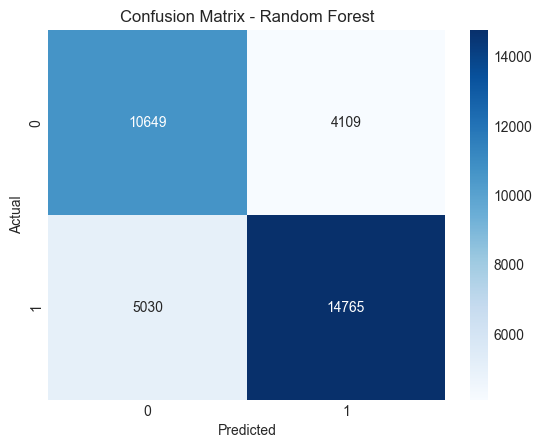

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_balanced)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
import pandas as pd

feature_importance = pd.Series(
    rf_model_balanced.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

order_hour                       0.248092
Days for shipment (scheduled)    0.162981
Order Region                     0.129163
Shipping Mode                    0.128302
order_month                      0.127507
Category Name                    0.086421
Type                             0.043181
Customer Segment                 0.041071
Department Name                  0.033282
dtype: float64


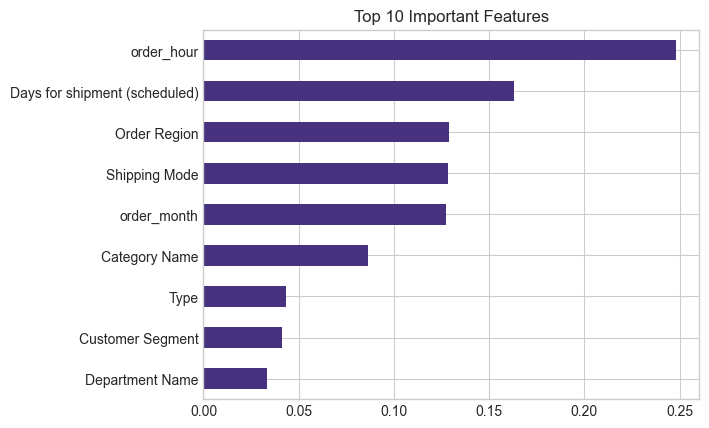

In [59]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [63]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=5,  
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_bal, y_train_bal)

print("Best Params:", random_search.best_params_)


Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 20}


In [64]:
best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_split=2,
    random_state=42
)

best_rf.fit(X_train_bal, y_train_bal)

RandomForestClassifier(max_depth=20, n_estimators=50, random_state=42)

In [66]:
y_pred_best = best_rf.predict(X_test)

In [67]:
evaluate_model(y_test, y_pred_best, "Tuned Random Forest")


--- Tuned Random Forest ---
Accuracy: 0.74
Precision: 0.83
Recall: 0.68

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.82      0.73     14758
           1       0.83      0.68      0.75     19795

    accuracy                           0.74     34553
   macro avg       0.74      0.75      0.74     34553
weighted avg       0.76      0.74      0.74     34553



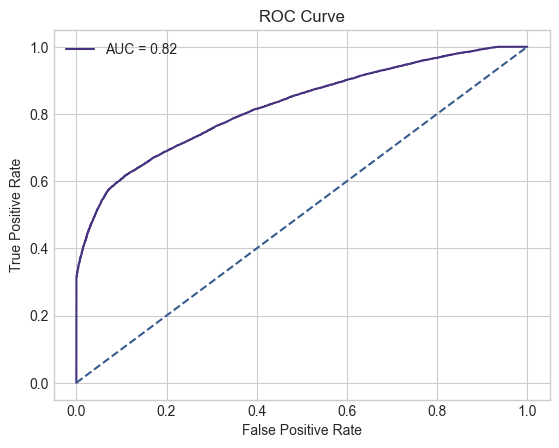

In [68]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 2)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()